# 📊 Training Analysis Notebook
Elegant visualizations for RL training metrics

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob, os
from scipy.integrate import trapezoid


plt.style.use('seaborn-v0_8-darkgrid')

# Custom color palette
colors = [
    "#0B84A5",  # azul petróleo
    "#F6C85F",  # amarillo oscuro
    "#6F4E7C",  # púrpura
    "#9DD866",  # verde
    "#CA472F"   # rojo ladrillo
]

In [68]:
DATA_PATH = './data/train'

files = glob.glob(
    os.path.join(DATA_PATH, 'training_steps_*.csv')
)

datasets = []

# =========================================================
# GROUP CURRICULUM FILES
# =========================================================

curriculum_groups = {}

for file in files:

    name = os.path.basename(file).lower()

    # -----------------------------------------------------
    # SCENARIO
    # -----------------------------------------------------
    if "simple" in name:
        escenario = "simple"

    elif "medium_transfer" in name:
        escenario = "medium_transfer"

    elif "complex_transfer" in name:
        escenario = "complex_transfer"

    elif "medium" in name:
        escenario = "medium"

    elif "complex" in name:
        escenario = "complex"

    else:
        escenario = "unknown"

    # =====================================================
    # PPO CURRICULUM
    # =====================================================
    if "ppo-curriculum" in name:

        if escenario not in curriculum_groups:
            curriculum_groups[escenario] = []

        curriculum_groups[escenario].append(file)

    # =====================================================
    # PLASTIC
    # =====================================================
    elif "plastic" in name:

        df = pd.read_csv(file)

        datasets.append({
            "escenario": escenario,
            "data": df[["steps", "episode_reward"]],
            "algo": "plastic",
            "name_in_graph": "Plastic (own)",
            "type": "transfer" if "transfer" in name else "scratch"
        })

    # =====================================================
    # PPO
    # =====================================================
    elif "ppo" in name:

        df = pd.read_csv(file)

        datasets.append({
            "escenario": escenario,
            "data": df[["steps", "episode_reward"]],
            "algo": "ppo",
            "name_in_graph": "PPO",
            "type": "transfer" if "transfer" in name else "scratch"
        })

# =========================================================
# MERGE CURRICULUM PHASES
# =========================================================

for escenario, scenario_files in curriculum_groups.items():

    exploration_file = None
    consolidation_file = None

    for f in scenario_files:

        if "exploration" in f:
            exploration_file = f

        elif "consolidation" in f:
            consolidation_file = f

    if exploration_file is None:
        continue

    # -----------------------------------------------------
    # LOAD EXPLORATION
    # -----------------------------------------------------
    df_exploration = pd.read_csv(exploration_file)

    merged_df = df_exploration.copy()

    # -----------------------------------------------------
    # LOAD CONSOLIDATION
    # -----------------------------------------------------
    if consolidation_file is not None:

        df_consolidation = pd.read_csv(consolidation_file)

        # IMPORTANT:
        # continue steps after exploration
        last_step = merged_df["steps"].max()

        df_consolidation["steps"] += last_step

        merged_df = pd.concat(
            [merged_df, df_consolidation],
            ignore_index=True
        )

    datasets.append({
        "escenario": escenario,
        "data": merged_df[["steps", "episode_reward"]],
        "algo": "ppo-curriculum",
        "name_in_graph": "PPO-curriculum",
        "type": "transfer" if "transfer" in exploration_file else "scratch"
    })

In [69]:
datasets[0].get("data")

,steps,episode_reward
0,3709,797.855487
1,9780,1582.350256
2,11759,399.374762
3,13017,192.708946
4,15735,672.476787
...,...,...
429,989513,586.717586
430,991023,952.362564
431,992394,1011.149229
432,993067,510.475305


## 📈 Learning Curve

In [70]:
def plot_scenario(type, scenario, datasets):
    fig, ax = plt.subplots(figsize=(10, 6))

    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")


    max_common_steps = min([
        d["data"]["steps"].max()
        for d in datasets
        if d.get("escenario") == scenario and d.get("type") == type
    ])

    common_steps = np.linspace(0, max_common_steps, 1000)

    color_idx = 0

    for dataset in datasets:

        if dataset.get("escenario") != scenario:
            continue
        if dataset.get("type") != type:
            continue

        df = dataset["data"].copy()

        df = df.sort_values("steps")
        x = df["steps"].values.astype(float)

        y = df["episode_reward"].values.astype(float)

        if len(x) < 2:
            continue

        # ---------------------------
        # 1. interpolation
        # ---------------------------
        interp_y = np.interp(common_steps, x, y)

        # ---------------------------
        # 2. smoothing low (EWMA)
        # ---------------------------
        alpha = 0.1
        smooth_y = pd.Series(interp_y).ewm(alpha=alpha).mean().values

        color = colors[color_idx % len(colors)]

        # ---------------------------
        # 3. principal line
        # ---------------------------
        ax.plot(
            common_steps,
            smooth_y,
            label=dataset.get("name_in_graph"),
            linewidth=2.5,
            color=color
        )

        std = np.std(interp_y)

        ax.fill_between(
            common_steps,
            smooth_y - std * 0.1,
            smooth_y + std * 0.1,
            color=color,
            alpha=0.12
        )

        color_idx += 1

 
    ax.set_title(f"Reward curve - {scenario.capitalize()}", fontsize=14, weight='bold')
    ax.set_xlabel("Training steps", fontsize=12)
    ax.set_ylabel("Episodic accumulated reward", fontsize=12)

    ax.legend(frameon=True, fontsize=10)
    # ax.grid(alpha=0.2)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    #fig.tight_layout()

    # ---------------------------
    # 4. save
    # ---------------------------
    filename = f"learning_curve_{scenario}_{type}.pdf"
    fig.savefig(filename, bbox_inches='tight')

    print(f"✅ Saved: {filename}")

    plt.show()
    plt.close(fig)

In [71]:
for d in datasets:
    if d["algo"] == "plastic":
        print(d["escenario"], d["type"])

medium scratch
simple scratch
medium_transfer transfer
complex_transfer transfer
complex scratch


✅ Saved: learning_curve_simple_scratch.pdf


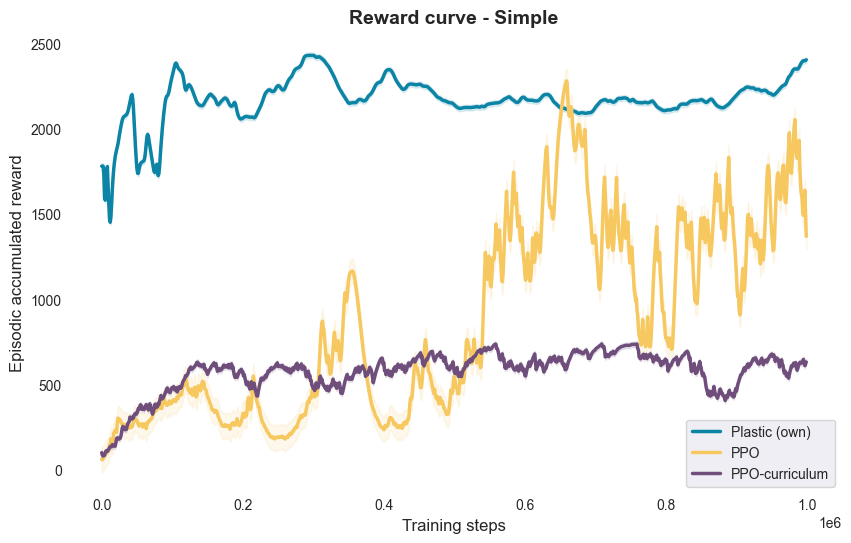

In [72]:
plot_scenario("scratch", "simple", datasets)

✅ Saved: learning_curve_medium_scratch.pdf


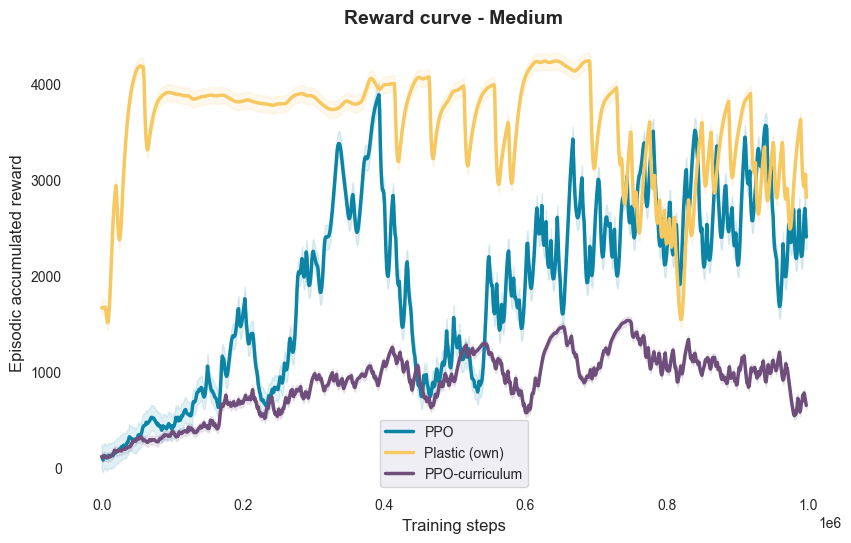

In [73]:

plot_scenario("scratch", "medium", datasets)


✅ Saved: learning_curve_complex_scratch.pdf


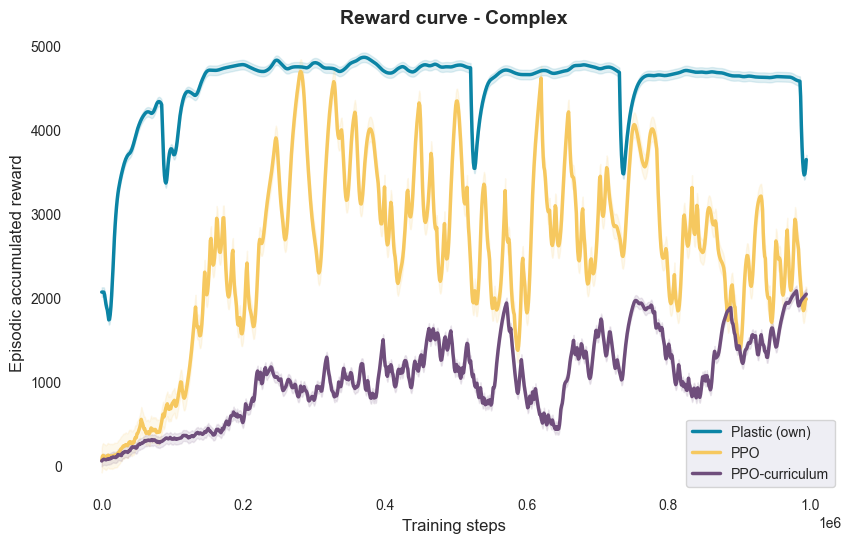

In [74]:
plot_scenario("scratch", "complex", datasets)

✅ Saved: learning_curve_medium_transfer_transfer.pdf


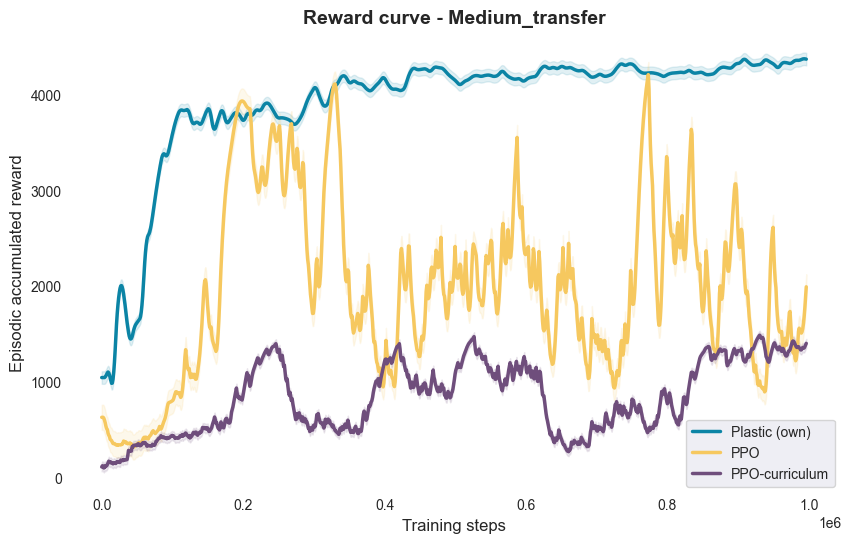

In [75]:
plot_scenario("transfer", "medium_transfer", datasets)


✅ Saved: learning_curve_complex_transfer_transfer.pdf


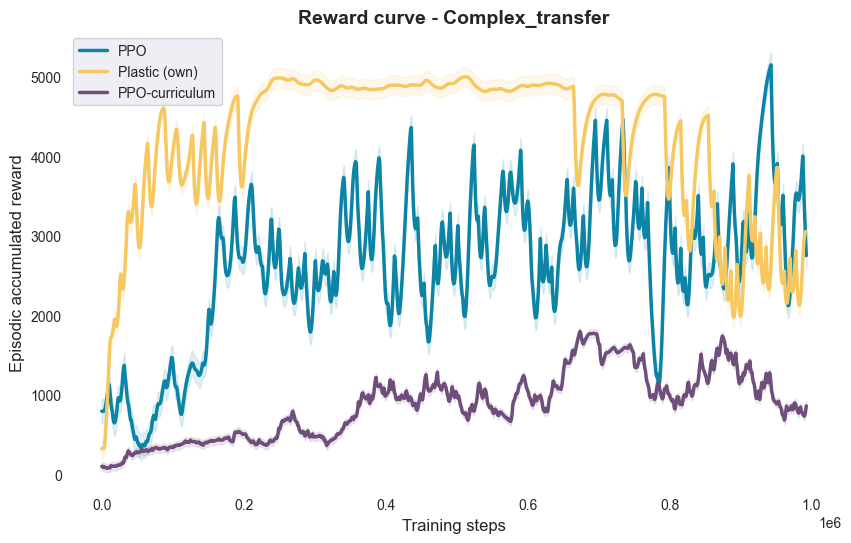

In [76]:
plot_scenario("transfer", "complex_transfer", datasets)

## 🎯 Steps to Threshold

## 📊 AUC

In [77]:
def plot_auc_all(datasets):

    colors = {
        "Plastic (own)": "#67be9b",
         "PPO": "#95add0",
        "PPO-curriculum": "#42c5f1"
    }

    auc_results = {}

    escenarios = sorted(set(d["escenario"] for d in datasets))
    tipos = sorted(set(d["type"] for d in datasets))

    # ---------------------------
    # 1. calcular AUC por grupo
    # ---------------------------
    for escenario in escenarios:
        for tipo in tipos:

            group_key = f"{escenario.capitalize()}-{tipo}"

            # filtrar datasets
            group_datasets = [
                d for d in datasets
                if d["escenario"] == escenario and d["type"] == tipo
            ]

            if len(group_datasets) == 0:
                continue

            # rango común
            max_common_steps = min(d["data"]["steps"].max() for d in group_datasets)
            common_steps = np.linspace(0, max_common_steps, 500)

            auc_results[group_key] = {}

            for dataset in group_datasets:

                df = dataset["data"].sort_values("steps").copy()

                df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
                df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")

                # df = df.dropna()
                # df = df.drop_duplicates("steps")

                x = df["steps"].values.astype(float)
                y = df["episode_reward"].values.astype(float)

                if len(x) < 2:
                    continue

                interp_rewards = np.interp(common_steps, x, y)

                window = 30
                smooth = np.convolve(interp_rewards, np.ones(window)/window, mode='same')

                auc = trapezoid(smooth, common_steps)
                auc_norm = auc / max_common_steps

                auc_results[group_key][dataset["name_in_graph"]] = auc_norm

    # ---------------------------
    # 2. construir gráfica
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12,6))

    group_names = list(auc_results.keys())
    methods = list(colors.keys())

    x = np.arange(len(group_names))
    width = 0.25

    for i, method in enumerate(methods):

        values = []

        for group in group_names:
            values.append(auc_results[group].get(method, 0))

        ax.bar(
            x + i * width,
            values,
            width,
            label=method,
            color=colors[method]
        )

    # etiquetas
    ax.set_xticks(x + width)
    ax.set_xticklabels(group_names, rotation=30)

    ax.set_ylabel("AUC")
    ax.set_title("AUC comparison across scenarios and training types", weight='bold')

    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # quitar bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig.savefig("auc_all_scenarios.pdf", bbox_inches='tight')

    plt.show()

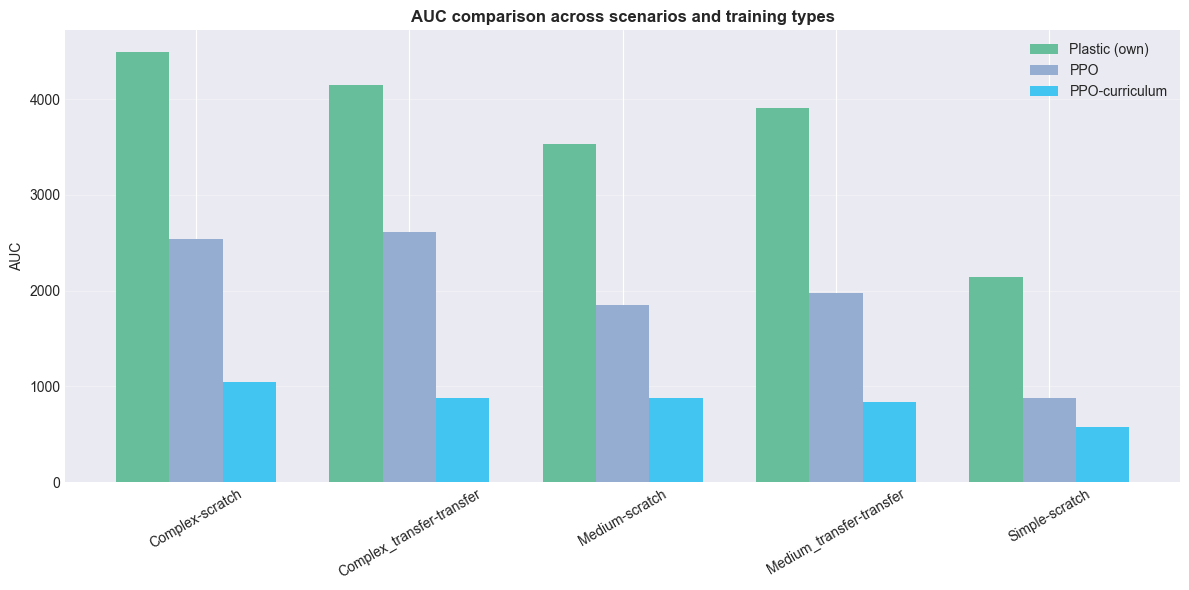

In [78]:
plot_auc_all(datasets)

## 📉 Stability

In [79]:
def plot_stability_all(datasets):

    colors = {
        "Plastic (own)": "#67be9b",
        "PPO": "#FFAC1C",
        "PPO-curriculum": "#f1db42"
    }

    stability_results = {}

    escenarios = sorted(set(d["escenario"] for d in datasets))
    tipos = sorted(set(d["type"] for d in datasets))

    # ---------------------------
    # 1. calcular estabilidad
    # ---------------------------
    for escenario in escenarios:
        for tipo in tipos:

            group_key = f"{escenario.capitalize()}-{tipo}"

            group_datasets = [
                d for d in datasets
                if d["escenario"] == escenario and d["type"] == tipo
            ]

            if len(group_datasets) == 0:
                continue

            stability_results[group_key] = {}

            for dataset in group_datasets:

                df = dataset["data"].copy()

                df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")
                df = df.dropna()

                if len(df) < 10:
                    continue

                # suavizado
                smooth = df["episode_reward"].rolling(20, min_periods=1).mean()

                # desviación móvil
                rolling_std = smooth.rolling(50, min_periods=1).std()

                # estabilidad global (menor = mejor)
                stability_value = rolling_std.mean()

                stability_results[group_key][dataset["name_in_graph"]] = stability_value

    # ---------------------------
    # 2. gráfica
    # ---------------------------
    fig, ax = plt.subplots(figsize=(12,6))

    group_names = list(stability_results.keys())
    methods = list(colors.keys())

    x = np.arange(len(group_names))
    width = 0.25

    for i, method in enumerate(methods):

        values = []

        for group in group_names:
            values.append(stability_results[group].get(method, np.nan))

        ax.bar(
            x + i * width,
            values,
            width,
            label=method,
            color=colors[method]
        )

    ax.set_xticks(x + width)
    ax.set_xticklabels(group_names, rotation=30)

    ax.set_ylabel("Reward Std (lower is better)")
    ax.set_title("Stability Across Scenarios and Training Types", weight='bold')

    ax.legend()
    ax.grid(axis='y', alpha=0.3)

    # quitar bordes
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    fig.tight_layout()

    fig.savefig("stability_all_scenarios.pdf", bbox_inches='tight')

    plt.show()

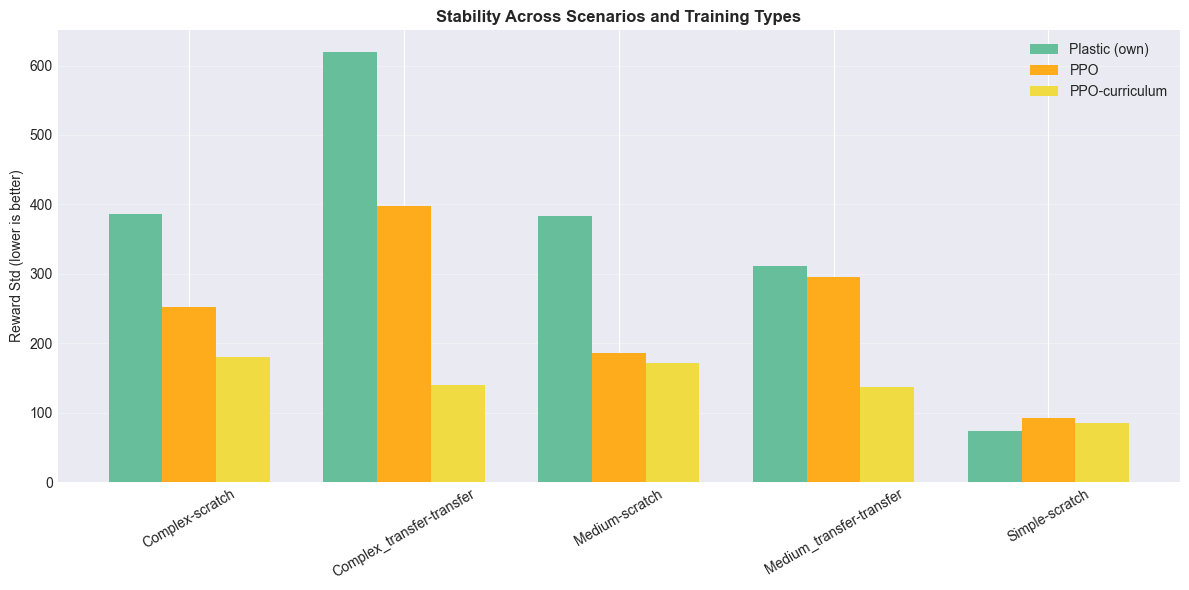

In [80]:
plot_stability_all(datasets)

### Plastic analisys

### metricas generales

In [81]:
auc_results = {}

for dataset in datasets:

    name = f"{dataset["name_in_graph"]} - {dataset["escenario"]}"
    df = dataset["data"].copy()

    # -------------------------
    # 1. limpiar
    # -------------------------
    df["steps"] = pd.to_numeric(df["steps"], errors="coerce")
    df["episode_reward"] = pd.to_numeric(df["episode_reward"], errors="coerce")

    df = df.sort_values("steps")

    steps = df["steps"].values.astype(float)
    rewards = df["episode_reward"].values.astype(float)

    if len(steps) < 2:
        auc_results[name] = np.nan
        continue

    # -------------------------
    # 2. suavizado
    # -------------------------
    window = 20
    rewards_smooth = np.convolve(
        rewards,
        np.ones(window) / window,
        mode="same"
    )

    # -------------------------
    # 3. AUC
    # -------------------------
    auc = trapezoid(rewards_smooth, steps)

    # -------------------------
    # 4. normalización
    # -------------------------
    total_steps = steps[-1]

    auc_normalized = auc / total_steps if total_steps > 0 else np.nan

    auc_results[name] = auc_normalized

In [82]:
auc_results

{'PPO - complex_transfer': np.float64(2017.5720031596613),
 'PPO - medium': np.float64(1418.3662828797014),
 'Plastic (own) - medium': np.float64(3358.2695010251714),
 'Plastic (own) - simple': np.float64(2138.590922376171),
 'Plastic (own) - medium_transfer': np.float64(3858.4170936883265),
 'PPO - simple': np.float64(703.6012637889767),
 'Plastic (own) - complex_transfer': np.float64(3911.686875794905),
 'PPO - medium_transfer': np.float64(1509.5060770955395),
 'Plastic (own) - complex': np.float64(4376.0540323110245),
 'PPO - complex': np.float64(2096.5610727742346),
 'PPO-curriculum - complex_transfer': np.float64(1178.5270514639835),
 'PPO-curriculum - simple': np.float64(827.5445095400369),
 'PPO-curriculum - medium': np.float64(1177.8179649945876),
 'PPO-curriculum - complex': np.float64(1821.0489494712326),
 'PPO-curriculum - medium_transfer': np.float64(1343.3876259230492)}

In [83]:
# -------------------------
# dict -> dataframe
# -------------------------
rows = []

for key, auc in auc_results.items():

    algorithm, scenario = key.split(" - ")

    rows.append({
        "algorithm": algorithm,
        "scenario": scenario,
        "auc": float(auc)
    })

df_auc = pd.DataFrame(rows)


df_grouped = (
    df_auc
    .groupby("algorithm")["auc"]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)


summary = (
    df_auc
    .groupby("algorithm")
    .agg(
        auc_mean=("auc", "mean"),
        auc_std=("auc", "std")
    )
    .reset_index()
)

summary

,algorithm,auc_mean,auc_std
0,PPO,1549.121340,559.621912
1,PPO-curriculum,1269.665220,361.134261
2,Plastic (own),3528.603685,856.570330


In [84]:
for data in datasets:
    rewards = data.get("data")["episode_reward"].values

    print(f"Episodic reward mean {data.get("name_in_graph")}", rewards.mean())

Episodic reward mean PPO 1519.1654372378687
Episodic reward mean PPO 932.4693541254553
Episodic reward mean Plastic (own) 3275.2043603395405
Episodic reward mean Plastic (own) 2166.498754191087
Episodic reward mean Plastic (own) 3910.3274678192665
Episodic reward mean PPO 494.7961895704754
Episodic reward mean Plastic (own) 3465.3321285777815
Episodic reward mean PPO 1259.5640110252202
Episodic reward mean Plastic (own) 4439.933976463082
Episodic reward mean PPO 1307.4250919599701
Episodic reward mean PPO-curriculum 851.2439450182978
Episodic reward mean PPO-curriculum 701.355673566059
Episodic reward mean PPO-curriculum 801.0436599375865
Episodic reward mean PPO-curriculum 992.2048236310125
Episodic reward mean PPO-curriculum 772.8627580445777


In [85]:
rows = []

for data in datasets:

    rewards = data["data"]["episode_reward"].values

    rows.append({
        "algorithm": data["name_in_graph"],
        "scenario": data["escenario"],
        "reward_mean": rewards.mean(),
        "reward_std": rewards.std(),
        "reward_max": rewards.max(),
    })

df_rewards = pd.DataFrame(rows)


summary_rewards = (
    df_rewards
    .groupby("algorithm")
    .agg(
        reward_mean=("reward_mean", "mean"),
        reward_std=("reward_mean", "std"),
        reward_max=("reward_max", "mean")
    )
    .reset_index()
)

print(summary_rewards)

        algorithm  reward_mean  reward_std   reward_max
0             PPO  1102.684017  399.527113  4616.109684
1  PPO-curriculum   823.742172  108.648982  4613.397332
2   Plastic (own)  3451.459337  847.057266  4282.639241
